# Livrable 2 :

In [1]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2025-04-16 16:09:22.202832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744812562.220591  128906 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744812562.225639  128906 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744812562.240606  128906 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744812562.240630  128906 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744812562.240632  128906 computation_placer.cc:177] computation placer alr

2.19.0


## Généation du dataset de photos

In [2]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="/mnt/c/Users/louag/Documents/CESI/Data_science/datasets/Photo")


Photo Dataset size: 9993


I0000 00:00:1744812565.120056  128906 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2012 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Bruitage du dataset

In [3]:
noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)
noisy_test_ds = data_loader.add_noise_to_dataset(test_ds)

2025-04-16 16:09:27.623733: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


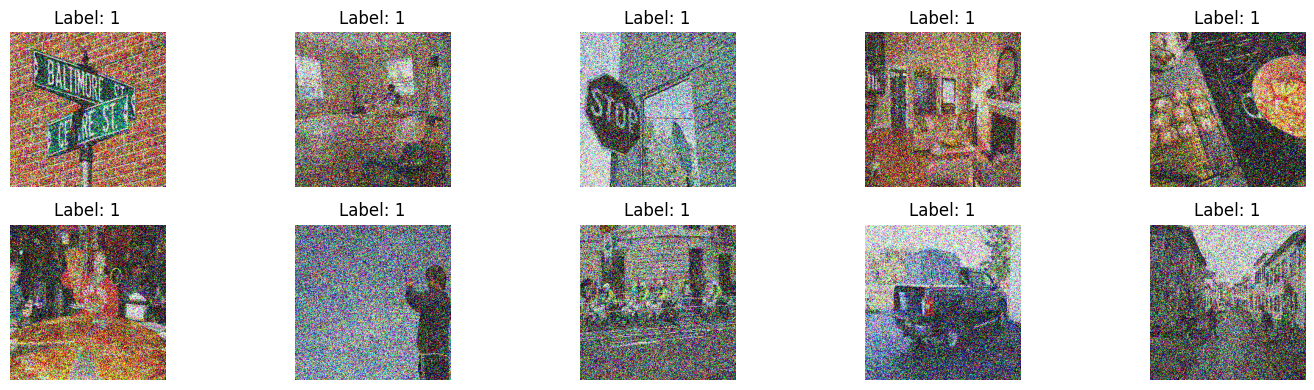

In [4]:
from src.utils import show_batch_images

show_batch_images(noisy_train_ds)

In [5]:
from keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU
from keras.models import Model

encoder_inputs = Input(shape=(256, 256, 3))  # Image RGB 256x256

# --- Block 1 ---
x1 = Conv2D(32, (3, 3), strides=2, padding='same')(encoder_inputs)  # (128, 128, 32)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU()(x1)

# --- Block 2 ---
x2 = Conv2D(64, (3, 3), strides=2, padding='same')(x1)  # (64, 64, 64)
x2 = BatchNormalization()(x2)
x2 = LeakyReLU()(x2)

# --- Block 3 ---
x3 = Conv2D(128, (3, 3), strides=2, padding='same')(x2)  # (32, 32, 128)
x3 = BatchNormalization()(x3)
x3 = LeakyReLU()(x3)

# --- Block 4 ---
x4 = Conv2D(256, (3, 3), strides=2, padding='same')(x3)  # (16, 16, 256)
x4 = BatchNormalization()(x4)
x4 = LeakyReLU()(x4)

# --- Block 5 ---
x5 = Conv2D(256, (3, 3), strides=2, padding='same')(x4)  # (8, 8, 256)
x5 = BatchNormalization()(x5)
x5 = LeakyReLU()(x5)

# Sorties : encoder_output + features pour skip connections
encoder = Model(inputs=encoder_inputs, outputs=[x5, x4, x3, x2, x1], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,440 (3.74 MB)

 Trainable params: 979,968 (3.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [6]:
from keras.layers import Conv2DTranspose, Concatenate, Input, BatchNormalization, LeakyReLU
from keras.models import Model

# Entrées : latent + les 4 couches skip
latent_input = Input(shape=(8, 8, 256))     # Sortie finale de l'encodeur
skip4 = Input(shape=(16, 16, 256))
skip3 = Input(shape=(32, 32, 128))
skip2 = Input(shape=(64, 64, 64))
skip1 = Input(shape=(128, 128, 32))

x = latent_input

# Decode Block 1
x = Conv2DTranspose(256, (3, 3), strides=2, padding='same')(x)  # (16, 16, 256)
x = Concatenate()([x, skip4])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 2
x = Conv2DTranspose(128, (3, 3), strides=2, padding='same')(x)  # (32, 32, 128)
x = Concatenate()([x, skip3])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 3
x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)  # (64, 64, 64)
x = Concatenate()([x, skip2])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 4
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (128, 128, 32)
x = Concatenate()([x, skip1])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 5 - reconstruction finale
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (256, 256, 32)
decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Modèle
decoder = Model(inputs=[latent_input, skip4, skip3, skip2, skip1], outputs=decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    590,080 │ input_layer_1[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_5[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_7[0]

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [7]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    590,080 │ input_layer_1[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_5[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_7[0]

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [8]:
from tensorflow.keras.models import Model

encoder_outputs = encoder(encoder_inputs)
decoded_img = decoder(encoder_outputs)

autoencoder = Model(inputs=encoder_inputs, outputs=decoded_img)

# Compilation de l'autoencodeur
autoencoder.compile(optimizer="adam", loss="mae", metrics=["accuracy"])

# Résumé du modèle
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 8, 8,     │    981,440 │ input_layer[0][0] │
│ (Functional)        │ 256), (None, 16,  │            │                   │
│                     │ 16, 256), (None,  │            │                   │
│                     │ 32, 32, 128),     │            │                   │
│                     │ (None, 64, 64,    │            │                   │
│                     │ 64), (None, 128,  │            │                   │
│                     │ 128, 32)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 256, 256,  │  1,387,619 │ encoder[0][0],    │
│ (Functional)        │ 3)                │            │ encoder[0][1],    │
│                     │                   │            │ encoder[0][2],    │
│                     │                   │            │ encoder[0][3],    │
│                     │                   │            │ encoder[0][4]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,369,059 (9.04 MB)

 Trainable params: 2,365,667 (9.02 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [9]:
@tf.autograph.experimental.do_not_convert
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [10]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

In [11]:
# Train the model
with tf.device("/gpu:0"):
    history = autoencoder.fit(train_autoenc_ds,
                    epochs=20,
                    batch_size= 32,
                    shuffle= True,
                    validation_data=val_autoenc_ds,
                    verbose=1
                   )

Epoch 1/20


2025-04-16 16:09:32.573574: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-04-16 16:09:32.573781: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1744812572.737346  129001 service.cc:152] XLA service 0x7f366c003150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744812572.737417  129001 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2025-

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5401 - loss: 0.1020

2025-04-16 16:10:22.767327: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 16 bytes spill stores, 16 bytes spill loads



200/200 ━━━━━━━━━━━━━━━━━━━━ 64s 218ms/step - accuracy: 0.5407 - loss: 0.1018 - val_accuracy: 0.6065 - val_loss: 0.1534
Epoch 2/20
  2/200 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.6806 - loss: 0.0710  

2025-04-16 16:10:32.812796: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.6796 - loss: 0.0693 - val_accuracy: 0.7073 - val_loss: 0.0733
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.6991 - loss: 0.0656 - val_accuracy: 0.6977 - val_loss: 0.0755
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.7058 - loss: 0.0637 - val_accuracy: 0.6984 - val_loss: 0.0726
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.7094 - loss: 0.0626 - val_accuracy: 0.7024 - val_loss: 0.0689
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.7127 - loss: 0.0617 - val_accuracy: 0.7074 - val_loss: 0.0707
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.7146 - loss: 0.0610 - val_accuracy: 0.7045 - val_loss: 0.0724
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.7169 - loss: 0.0603 - val_accuracy: 0.7060 - val_loss: 0.0704
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.7193 - loss: 0.0598 - val_acc

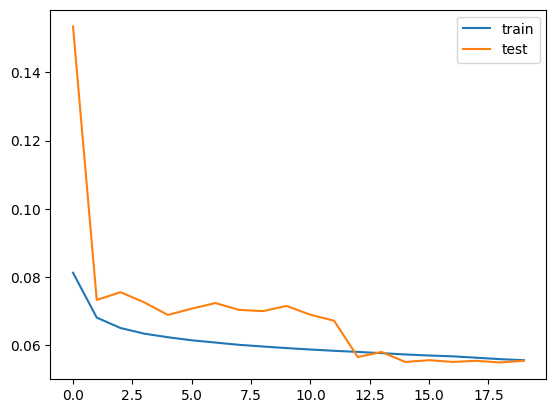

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


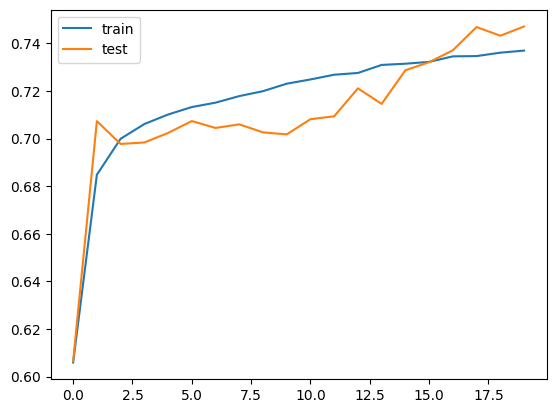

In [14]:

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()

In [15]:
def show_original_vs_decoded(noisy_dataset, clean_dataset, model, n=10):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise ImportError()
    
    noisy_images, _ = next(iter(noisy_dataset))
    clean_images, _ = next(iter(clean_dataset))

    decoded_images = model.predict(noisy_images)

    plt.figure(figsize=(15, 6))
    for i in range(n):

        # Image bruitée (entrée)
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].numpy())
        plt.title("Bruitée")
        plt.axis("off")

        #  Image originale non bruitée 
        ax = plt.subplot(3, n, n + i + 1)
        plt.imshow(clean_images[i].numpy())
        plt.title("Originale")
        plt.axis("off")

        # Image reconstruite
        ax = plt.subplot(3, n, 2 * n + i + 1)
        plt.imshow(decoded_images[i])
        plt.title("Reconstruite")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step


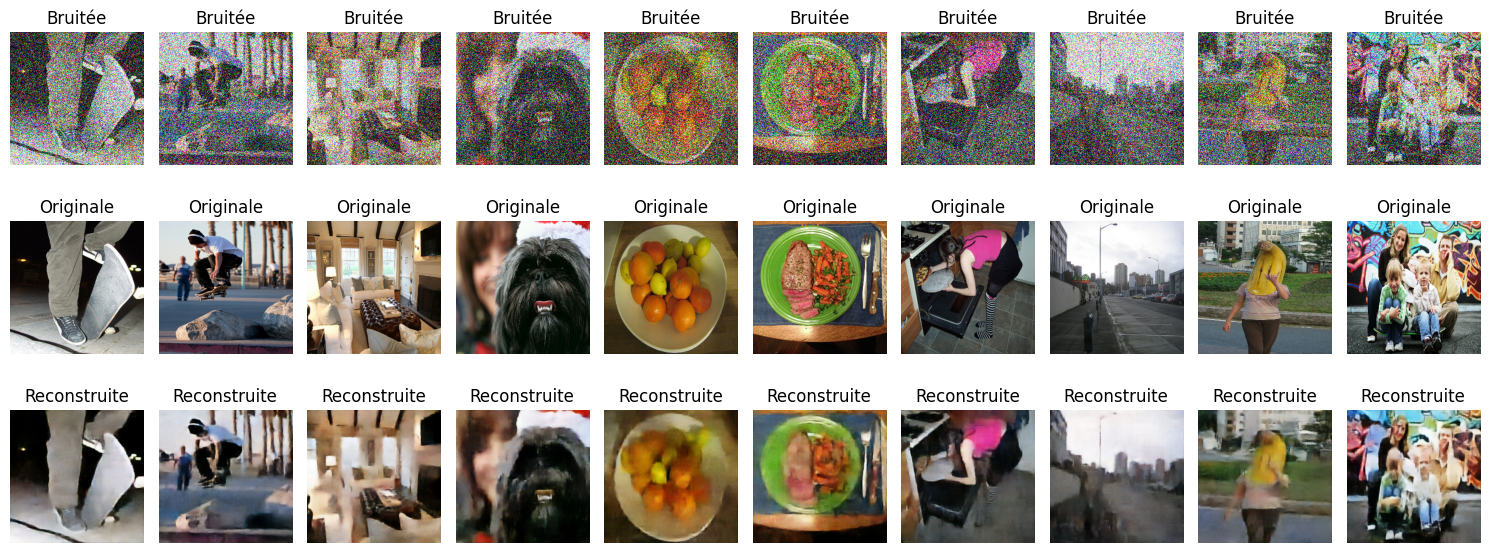

In [16]:
show_original_vs_decoded(noisy_test_ds, test_ds, autoencoder)